## Table of Contents
1. [Introduction](#introduction)
2. [Methods](#methods)

   2.1. [Preprocessing](#preprocessing)
      * [Terminology & examples](#some-terminology)

   2.2. [Extracting shared constructions](#extracting-shared-constructions)

   2.3. [Filtering shared constructions](#linking-shared-constructions)

   2.4. [Linking shared constructions](#linking-shared-constructions)
      * [Example](#example)

3. [Analysis & results](#results)

   3.1. [Presence of Shared Constructions and their Patterns of Use over Dialogue Rounds](#presence_alignment)
   
   3.2. [Individual Speaker Names versus Interactive Shared Constructions](#individual_vs_shared) 
        
   3.3. [Naming Convergence Across Speakers is Linked to Shared Constructions](#naming_convergence)


### Note: please note that, in this notebook, we use the term "construction" to refer to a sequence of lemmas that is repeated across multiple dialogues. This term is used interchangeably with "expression".

### !!! Before running this script, please run the dialing.jar file with the following command after changing the current directory to the dialign folder:
`java -jar dialign.jar -i targets_zoom_lemma_lg -o output_targets_zoom_lemma_lg`


### Import libraries & methods <a class="anchor" id="importing_libraries"></a>

In [1]:
# code to import python libraries and set up the notebook
import seaborn as sns
import pandas as pd
import numpy as np
import colorcet as cc

from read_labeled_and_pos_target_data import assert_match_betwee_shared_exp_and_actual_utterances, prepare_dialogue_shared_expressions_and_turns_info, extract_all_shared_exp_info, all_func_words
from link_target_expressions import link_shared_expressions_final_algo, link_identical_shared_expressions_based_on_pair, link_shared_expressions_fribble_based
from prepare_annotate_dialogues_adapted import get_turn_info
from read_stop_function_words import read_stop_function_words
from data_classes import Tier, Turn, Utterance, Gesture 


import spacy
from similarity_measures import get_naming_task
# use genism to load the word2vec model

from read_labeled_and_pos_target_data_pseudo import prepare_dialogue_shared_expressions_and_turns_info_pseudo 

pd.set_option("display.precision", 2)
palette = sns.color_palette(cc.glasbey_hv, n_colors=25)
sns.set_theme(style="whitegrid", palette=palette) 

c:\Users\shoaka\Anaconda3\envs\lexical_alignment\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\shoaka\Anaconda3\envs\lexical_alignment\lib\site-packages\pyannote\audio\core\io.py:43: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("soundfile")
c:\Users\shoaka\Anaconda3\envs\lexical_alignment\lib\site-packages\pyannote\audio\pipelines\speaker_verification.py:43: UserWarning: torchaudio._backend.get_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  backend = torchaudio.get_audio_backend()
c:\Users\shoaka\Anaconda3\envs\lexical_alignment\lib\inspect.py:746: UserWarning: Module 'speechbrain.pretrained' 

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
space_lg_nlp = spacy.load("nl_core_news_lg")
# naming_task = get_naming_task(nlp=space_lg_nlp) # change to zoom data naming task

In [12]:
# code to set up the paths
dataset = "small" # "zoom" or "small"
dialign_output = f'../../dialign/output_targets_{dataset}_lemma_lg/'
turn_info_path = f'../../dialign/targets_{dataset}_lemma_lg/'
output_folder = '../../data/cabb_small/' if dataset == "small" else '../../data/zoom/'
pos_func_words = ['DET', 'PRON', 'ADP', 'CCONJ', 'SCONJ', 'AUX', 'PART', 'PUNCT', 'SYM', 'X', 'INTJ', 'NUM', 'SPACE']
frequent_words, function_words = read_stop_function_words()

# 1. Introduction <a class="anchor" id="introduction"></a>
<!-- # ~/anaconda3/envs/lex/bin/pip install statannotations
# /Users/esamghaleb/anaconda3/bin/pip install spacy -->
This notebook includes the data processing methods used to operationalise linguistic alignment and the results reported in the paper. Linguistic alignment is detected based on a lemmatized speech at the level of the lemmas' form. In a Pairs, single lemmas or sequences of lemmas used at least once by **both** participants are defined as shared expressions and considered instances of lexical linguistic.

# 2. Methods<a class="anchor" id="methods"></a>

# 2.1. Pre-processing Dialogues and Extracting Shared Constructions <a class="anchor" id="preprocessing"></a>
The details of the pre-processing steps are described README.md file in the main directory of the project.

## Some terminology <a class="anchor" id="some-terminology"></a>

* **Initiation turn/round:** The turn or round where a shared expression was first introduced by one of the participants.
* **Establishing turn/round:** The turn or round where the shared expression was first repeated by the other participant, i.e., it becomes shared.
* **Speaker role:** **D** & **M** indicate whether the shared expression was used by the director or the matcher.
* **Initiator role:** The participant who introduced the shared expression, i.e., the director or the matcher.
* **Establisher role:** The participant who established the shared expression, i.e., the director or the matcher.
* **Turns** and **rounds:** the turns and rounds numbers where shared expressions are used. 
* **Length:** the number of lemmas in the shared expression.
* **Target fribble:** the fribble for which the shared expression was used.
* **Frequency:** the number of times the shared expression was used.

In [5]:
pos_func_words = ['DET', 'PRON', 'ADP', 'CCONJ', 'SCONJ', 'AUX', 'PART', 'PUNCT', 'X', 'INTJ', 'SPACE', 'NUM'] # 'SYM' removed
stop_words, function_words = read_stop_function_words()

# 2.2. Extracting shared constructions <a class="anchor" id = "extracting-shared-constructions"></a>

The steps to extract shared constructions are explained in the README.md file in the main directory of the project. In this notebook, we load the extracted shared constructions and analyse them. We load the shared constructions for real and control dialogues and compare them.


### Load shared constructions of real dialogues

In [7]:
# code to read the shared expressions and turns info of real pairs
real_shared_constructions_info, real_turns_info = prepare_dialogue_shared_expressions_and_turns_info(dialign_output, turn_info_path)
real_exp_info = extract_all_shared_exp_info(real_shared_constructions_info, real_turns_info)

100%|██████████| 19/19 [00:14<00:00,  1.27it/s]


In [8]:
# n = len(real_turns_info["001"])
# utterances = []
# rounds = []
# for i in range(n):
#     utterance = real_turns_info["001"][i].utterance
#     round = real_turns_info["001"][i].round
#     utterances.append(utterance)
#     rounds.append(round)

### Load shared constructions of Pseudo Pairs (control dialogues)

In [9]:
# pseudo_shared_constructions_info, pseudo_turns_info = prepare_dialogue_shared_expressions_and_turns_info_pseudo(pseudo_dialign_output, pseudo_turn_info_path)
# pseudo_exp_info = extract_all_shared_exp_info(pseudo_shared_constructions_info, pseudo_turns_info)

# 2.3. Filtering shared constructions <a class="anchor" id="filtering-shared-constructions"></a>
We filter out shared constructions consisting only of function words or very common words. To identify function words, we use POS tagging and remove phrases that only contain them. We also consider highly frequent words based on word frequencies in the SUBTLEX-NL corpus. We focus on shared constructions used by one fribble in the entire dialogue and set aside those used for multiple fribbles for future analysis. This gives us a set of unique shared constructions per fribble, representing the contentful lemmas used exclusively by both participants for each fribble.

More details on the filtering process are provided in the README.md file in the main directory of the project.

In [8]:
def clean_exp_info(exp_info, function_words, stop_words):
   exp_with_only_func_words = np.logical_not([all_func_words(pos_seq, pos_func_words) for idx, pos_seq in enumerate(exp_info['pos_seq'].to_list())])
   exp_info = exp_info[exp_with_only_func_words]
   exp_with_only_func_words = np.logical_not([all_func_words(exp, function_words) for idx, exp in enumerate(exp_info['exp'].to_list())])
   exp_info = exp_info[exp_with_only_func_words]
   exp_with_only_stop_words = np.logical_not([all_func_words(exp, stop_words) for idx, exp in enumerate(exp_info['exp'].to_list())])
   exp_info = exp_info[exp_with_only_stop_words]
   return exp_info

def link_exp_info(exp_info, turns_info, shared_constructions_info):
   exp_info['shared expressions'] = exp_info['exp'].apply(lambda x: [x])
   exp_info = link_identical_shared_expressions_based_on_pair(turns_info, exp_info)
   # check if there are nan values in exp_info
   assert not exp_info.isnull().values.any()
   # exp_info = exp_info[exp_info['#fribbles'] == 1] # this is disabled for the zoom project
   # Here, we assert that all detected shared expressions are in the original lemmatized utterances, with matching turn numbers
   assert_match_betwee_shared_exp_and_actual_utterances(turns_info, shared_constructions_info)
   return exp_info

real_exp_info_clean = clean_exp_info(real_exp_info, function_words, stop_words)
# pseudo_exp_info = clean_exp_info(pseudo_exp_info, function_words, stop_words)

real_exp_info_linked = link_exp_info(real_exp_info_clean, real_turns_info, real_shared_constructions_info)
# pseudo_exp_info = link_exp_info(pseudo_exp_info, pseudo_turns_info, pseudo_shared_constructions_info)


## 2.4. Linking shared constructions with a common lexical core <a class="anchor" id="linking-shared-constructions"></a>

The methods described above may result in sets of unique shared expressions per fribble that contain highly overlapping expressions. For example, for fribble 14, pair 10 uses the shared expressions "de bal bovenop" and "de bal," which overlap significantly. To identify such overlaps, we use regular expressions and link the expressions based on the overlap of content lemmas. We do not link the expressions if the overlapping sequence contains only function words.

This process produces sets of shared expression types that reflect a common underlying conceptualization or lexical core, which we consider instances of lexical alignment. To simplify the labeling of these types, we assign a common lexical core as the label, which is the shortest common sequence for the set. For instance, Pair 5 has three sets of shared expressions, each labeled with a common lexical core, such as "paddestoel," which includes three shared expressions: "een paddestoel," "een paddestoel op zijn hoofd," and "paddestoel op zijn hoofd."

To illustrate the linking process of shared expressions, consider the example below for Pair 5 and Fribble 1.
<!-- > **PLOT** include plot for Pair 5 example after linking; for each occurance include which speaker (A,B) utters it. -->

In [9]:
from link_target_expressions import final_linking_algo_individually
real_fribble_specific_exp_info = final_linking_algo_individually(real_turns_info, real_exp_info_linked, real_shared_constructions_info, function_words, pos_func_words, pseudo_pairs=False, frequent_words=frequent_words)
# pseudo_fribble_specific_exp_info = final_linking_algo_individually(pseudo_turns_info, pseudo_exp_info, pseudo_shared_constructions_info, function_words, pos_func_words, pseudo_pairs=True, frequent_words=frequent_words)

c:\Users\shoaka\ownCloud\Project\PhD_Project\Chapter3_f2f_zoom\Analysis\lexical-alignment\code\notebooks\utils\link_target_expressions.py:410: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_pair_fribble_exp_info['target_fribble'] = [target_fribble] * target_pair_fribble_exp_info.shape[0]
c:\Users\shoaka\ownCloud\Project\PhD_Project\Chapter3_f2f_zoom\Analysis\lexical-alignment\code\notebooks\utils\link_target_expressions.py:410: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_pair_fribble_exp_info

In [10]:
### remove duplicate timestamps from real_fribble_specific_exp_info, as the algorithm produced duplicate timestamps for some labels
### we will do this only if the frequency and len(from_ts) are different
real_fribble_specific_exp_info['from_ts_unique'] = real_fribble_specific_exp_info['from_ts'].apply(lambda x: list(dict.fromkeys(x)))
real_fribble_specific_exp_info['to_ts_unique'] = real_fribble_specific_exp_info['to_ts'].apply(lambda x: list(dict.fromkeys(x)))
real_fribble_specific_exp_info['ts_len'] = real_fribble_specific_exp_info['from_ts'].apply(lambda x: len(x))
real_fribble_specific_exp_info['from_ts'] = np.where(real_fribble_specific_exp_info['freq'] != real_fribble_specific_exp_info['ts_len'], 
                                        real_fribble_specific_exp_info['from_ts_unique'], # if the condition is True
                                        real_fribble_specific_exp_info['from_ts']) # if the condition is False
real_fribble_specific_exp_info['to_ts'] = np.where(real_fribble_specific_exp_info['freq'] != real_fribble_specific_exp_info['ts_len'],
                                      real_fribble_specific_exp_info['to_ts_unique'], # if the condition is True
                                      real_fribble_specific_exp_info['to_ts']) # if the condition is False

In [13]:
real_fribble_specific_exp_info_clean = real_fribble_specific_exp_info.drop_duplicates(subset=['exp', 'pair']).sort_values(by=['pair', 'turns_to_emerge'])
real_fribble_specific_exp_info_clean.to_csv(output_folder + 'exp_info.csv', index=False)

print(f"#shared expressions before dropping duplicates: {len(real_fribble_specific_exp_info)}")
print(f"#shared expressions after dropping duplicates: {len(real_fribble_specific_exp_info_clean)}")

#shared expressions before dropping duplicates: 1991
#shared expressions after dropping duplicates: 1259


## Example <a class="anchor" id="example"></a>
To illustrate the linking process of shared expressions, consider the example below for Pair 5 and Fribble 1.

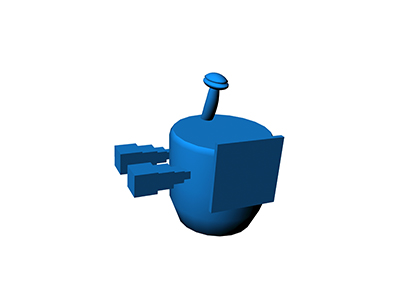

,shared construction types,shared constructions,freq,speakers,speaker role,initiator role,establisher role,rounds
0,deze hebben een paddestoel op zijn hoofd,[deze hebben een paddestoel op zijn hoofd],2,"[B, A]","[D, D]",[D],[D],"[3, 4]"
1,paddestoel op zijn hoofd,[paddestoel op zijn hoofd],4,"[A, B, A, A]","[D, D, D, D]",[D],[D],"[2, 3, 4, 6]"
2,twee vierkant schroef,[twee vierkant schroef],3,"[B, A, B]","[D, D, M]",[D],[D],"[1, 4, 6]"
3,een scherm,[een scherm],2,"[B, A]","[D, D]",[D],[D],"[3, 4]"
4,paddestoel,[paddestoel],5,"[A, B, A, B, A]","[D, D, D, D, D]",[D],[D],"[2, 3, 4, 5, 6]"


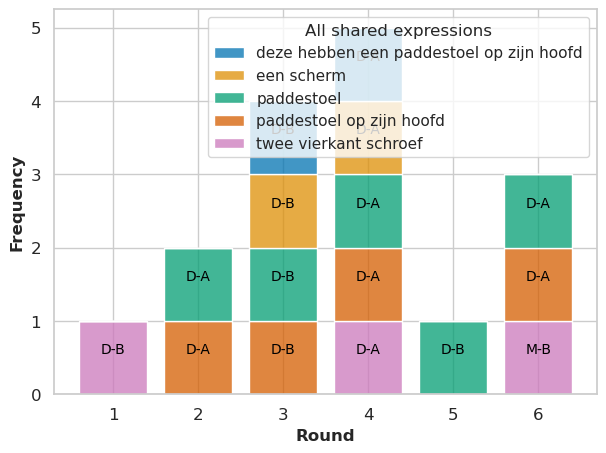

#################################### shared expressions after linking ####################################


,shared construction types,shared constructions,freq,speakers,speaker role,initiator role,establisher role,rounds
0,paddestoel,"[paddestoel op zijn hoofd, deze hebben een paddestoel op zijn hoofd, paddestoel]",5,"[A, B, A, B, A]","[D, D, D, D, D]",[D],[D],"[2, 3, 4, 5, 6]"
1,twee vierkant schroef,[twee vierkant schroef],3,"[B, A, B]","[D, D, M]",[D],[D],"[1, 4, 6]"
2,een scherm,[een scherm],2,"[B, A]","[D, D]",[D],[D],"[3, 4]"


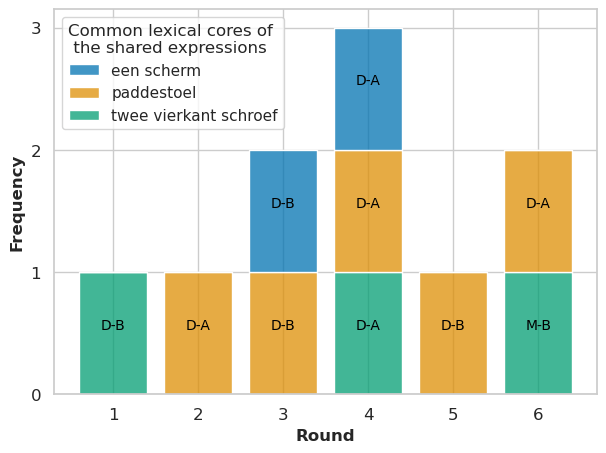

In [12]:
num_fribbles = 1
target_fribble = '01'
target_pair = 'pair05'
pair = target_pair
real_exp_info['number of rounds'] = real_exp_info.apply(lambda x: len(np.unique(x['rounds'])), axis=1)
real_exp_info['label'] = real_exp_info['exp']
linked_expressions = link_shared_expressions_fribble_based(real_turns_info, real_exp_info, function_words, pos_func_words, num_fribbles=num_fribbles, target_fribble=target_fribble, target_pair=target_pair, fribbles_path=fribbles_path, videos_path=videos_path, save_clips=False)